In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("superstore.csv", encoding="latin1")
dataset.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
print("Shape: ", dataset.shape)
print("\nMissing Values: ")
print(dataset.isnull().sum())
print("\nData Types: ")
print(dataset.dtypes)

Shape:  (9994, 21)

Missing Values: 
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types: 
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: objec

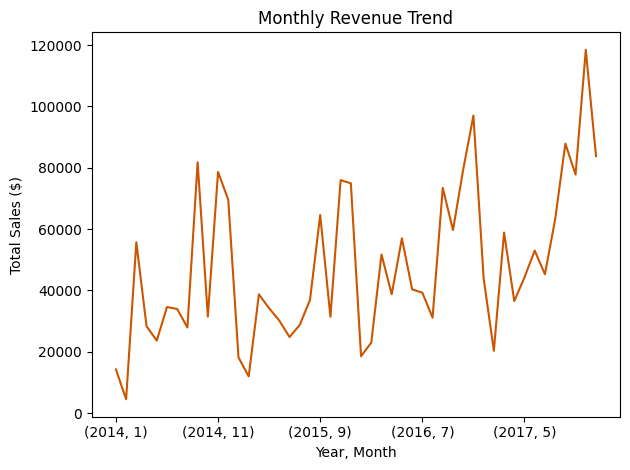

In [9]:
#converting orderdate to datetime
dataset["Order Date"] = pd.to_datetime(dataset["Order Date"])

dataset["Year"] = dataset["Order Date"].dt.year
dataset["Month"] = dataset["Order Date"].dt.month

dataset[["Order Date", "Year", "Month"]].head()

#monthly revenue trends
monthly_sales = dataset.groupby(["Year", "Month"])["Sales"].sum()

monthly_sales.plot(kind="line",color="#CC5500")
plt.title("Monthly Revenue Trend")
plt.xlabel("Year, Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


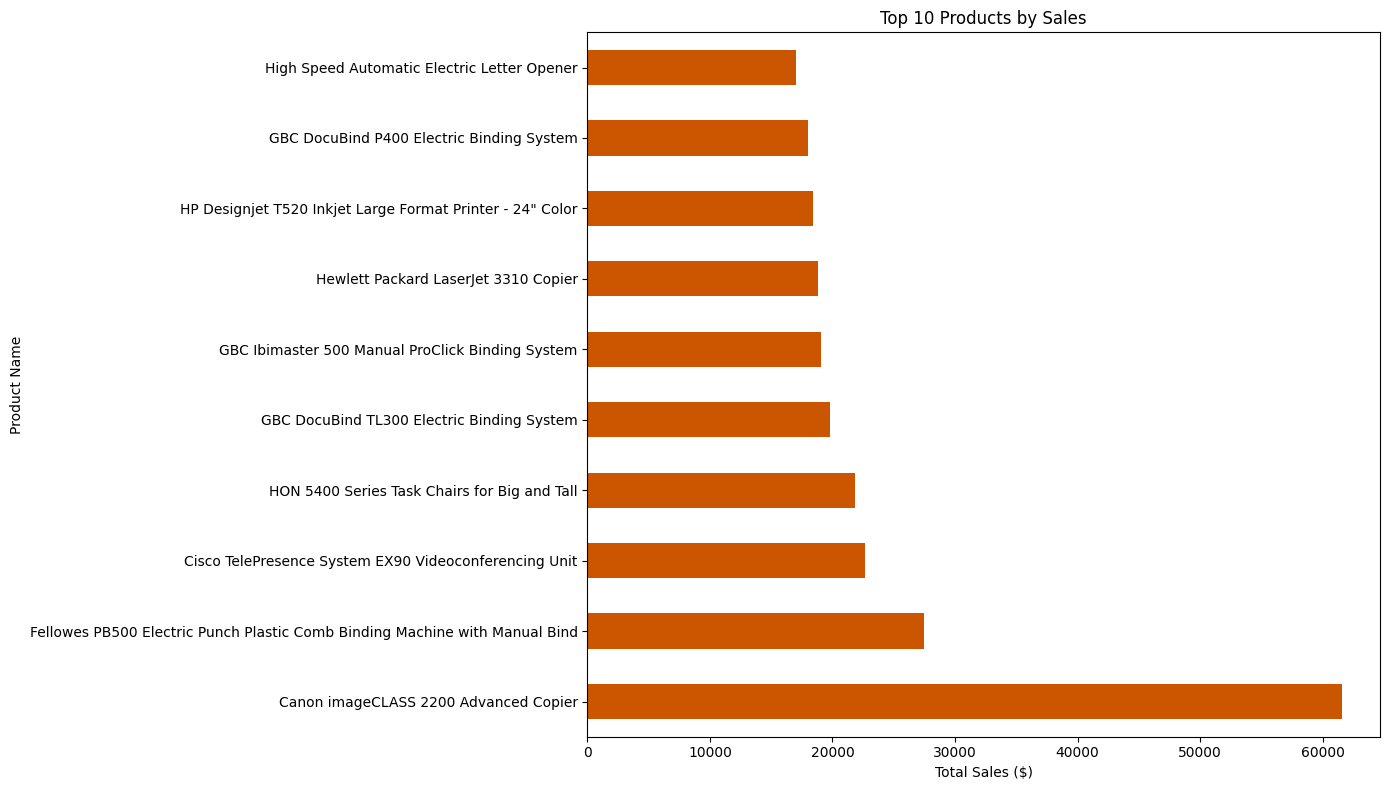

In [ ]:
#Top Selling Products
top_products = dataset.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,8)) #14 wide, 8 tall
top_products.plot(kind="barh", color="#CC5500")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

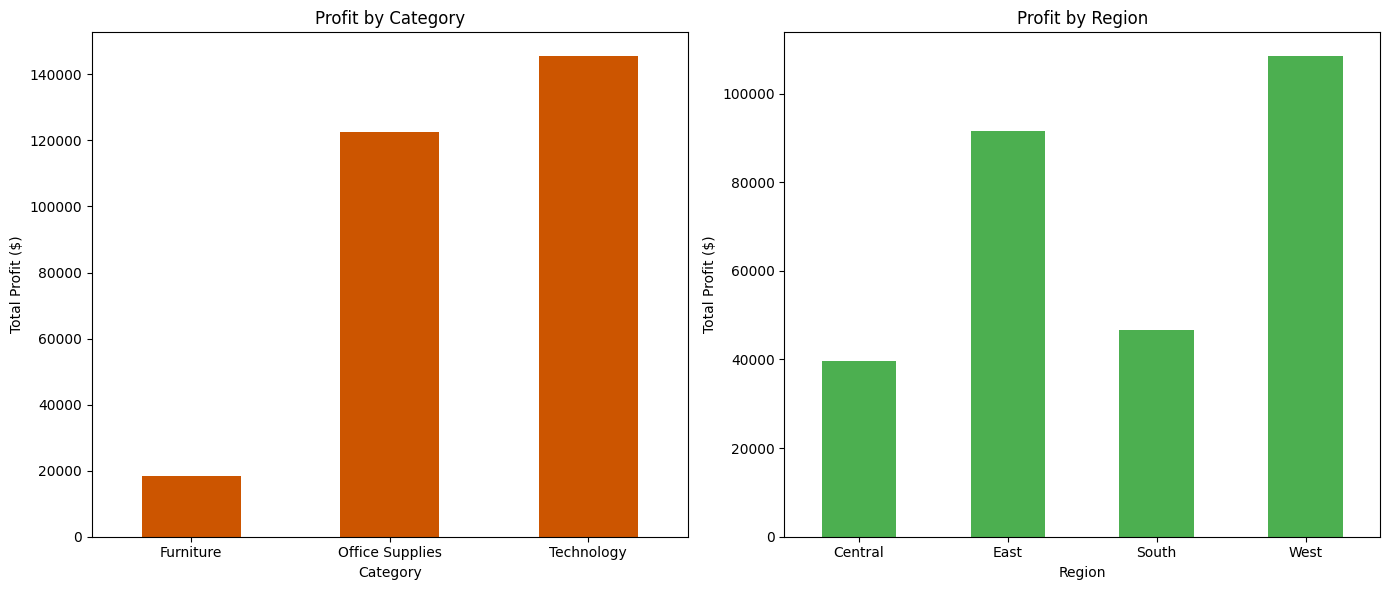

In [14]:
#Profit Analysis
fig, axes = plt.subplots(1,2, figsize=(14,6))

#profit by category
category_profit = dataset.groupby("Category")["Profit"].sum()
category_profit.plot(kind="bar", ax=axes[0], color="#CC5500")
axes[0].set_title("Profit by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Profit ($)")
axes[0].tick_params(axis="x", rotation=0)

#profit by region
region_profit = dataset.groupby("Region")["Profit"].sum()
region_profit.plot(kind="bar", ax=axes[1], color="#4CAF50")
axes[1].set_title("Profit by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Total Profit ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

